In [61]:
# Solar Battery Optimization: A Predict-Then-Optimize Pipeline

#This notebook demonstrates an end-to-end pipeline that:
#1. Forecasts solar generation using Random Forest
#2. Optimizes battery charge/discharge scheduling using MILP
#3. Minimizes grid electricity costs over a 24-hour horizon

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_p1_gen_data = pd.read_csv("Plant_1_Generation_Data.csv")
df_p1_weather_data = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

df_p2_gen_data = pd.read_csv("Plant_2_Generation_Data.csv")
df_p2_weather_data = pd.read_csv("Plant_2_Weather_Sensor_Data.csv")

The following issues were observed from the above cell


1.   There are multiple source keys for the same plant in the same hour in the gen_data file. this means we cannot merge the weather file with this one directly
2.   Date formats are different DD-MM-YYYY vs the reverse

On pd.merge 'how'
left — keep all generation timestamps, fill weather columns with NaN if no match
right — keep all weather timestamps, fill generation columns with NaN if no match
inner — only keep timestamps that exist in both tables
outer — keep everything from both, NaN where no match

In [62]:
#Fix datetime formats
df_p1_gen_data['DATE_TIME'] = pd.to_datetime(df_p1_gen_data['DATE_TIME'], format='%d-%m-%Y %H:%M')
df_p1_weather_data['DATE_TIME'] = pd.to_datetime(df_p1_weather_data['DATE_TIME'])
#aggregate all inverter outputs into plant level totals
df_p1_gen_data_agg = df_p1_gen_data.groupby('DATE_TIME').agg(
    DC_POWER = ('DC_POWER','sum'),
    AC_POWER = ('AC_POWER','sum'),
    DAILY_YIELD = ('DAILY_YIELD','sum'),

).reset_index()

#merge this aggregated one with weather
df_p1_merged = pd.merge(df_p1_gen_data_agg, df_p1_weather_data[['DATE_TIME', 'AMBIENT_TEMPERATURE','MODULE_TEMPERATURE', 'IRRADIATION']], on='DATE_TIME', how='inner')


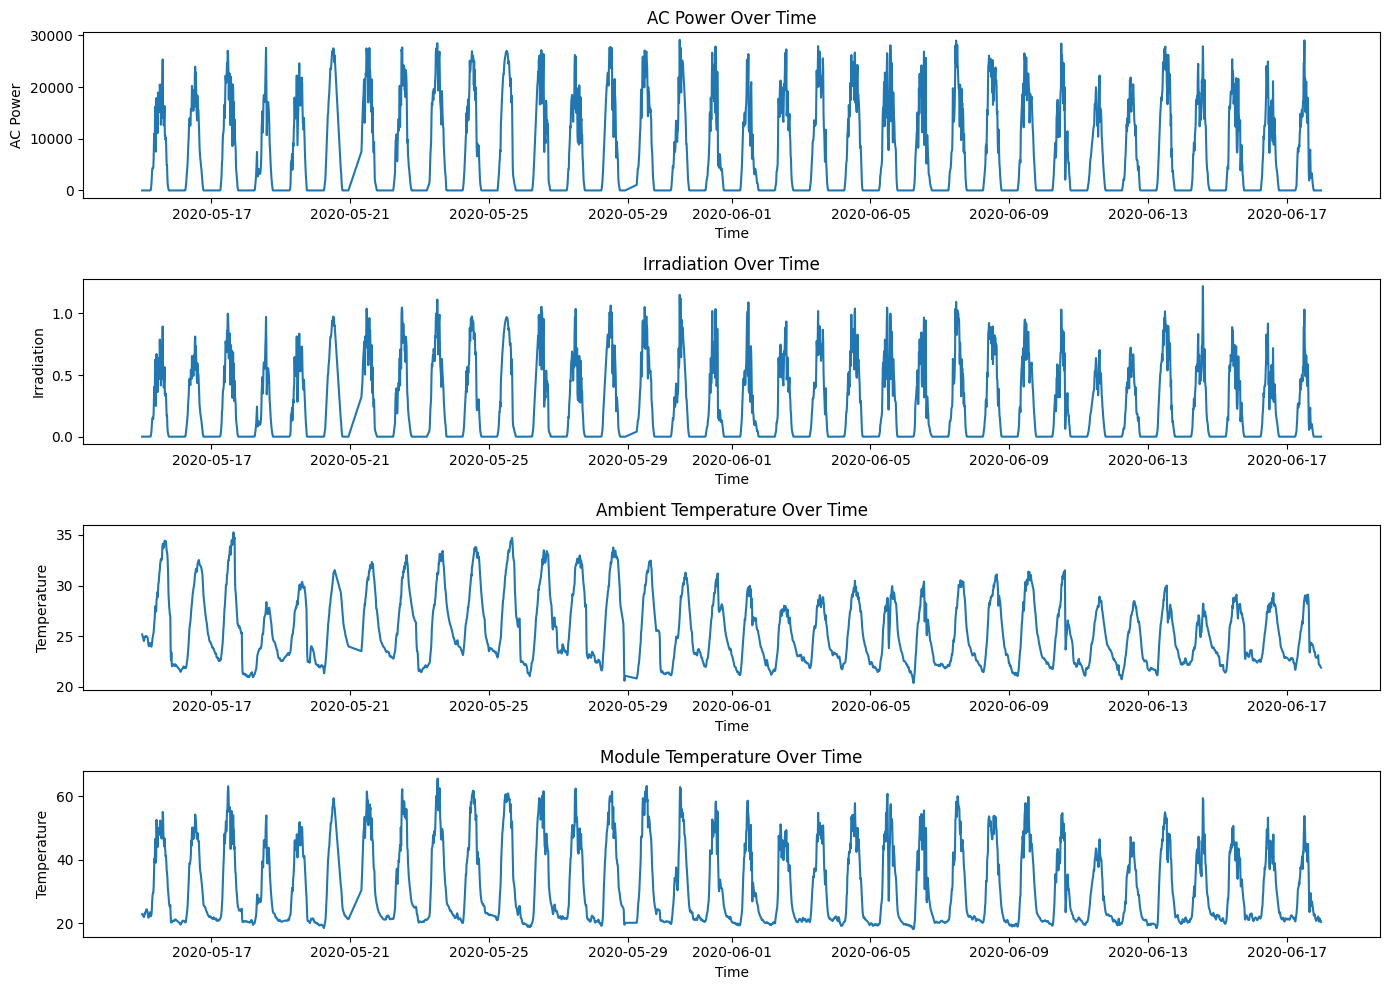

In [63]:
fig, axes = plt.subplots(4, 1, figsize=(14,10))

#AC power over time
axes[0].plot(df_p1_merged['DATE_TIME'], df_p1_merged['AC_POWER'])
axes[0].set_title('AC Power Over Time')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('AC Power')

#irradiation over time
axes[1].plot(df_p1_merged['DATE_TIME'], df_p1_merged['IRRADIATION'])
axes[1].set_title('Irradiation Over Time')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Irradiation')

#temperature over time
axes[2].plot(df_p1_merged['DATE_TIME'], df_p1_merged['AMBIENT_TEMPERATURE'])
axes[2].set_title('Ambient Temperature Over Time')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Temperature')
#module temperature over time
axes[3].plot(df_p1_merged['DATE_TIME'], df_p1_merged['MODULE_TEMPERATURE'])
axes[3].set_title('Module Temperature Over Time')
axes[3].set_xlabel('Time')
axes[3].set_ylabel('Temperature')
plt.tight_layout()
plt.show()

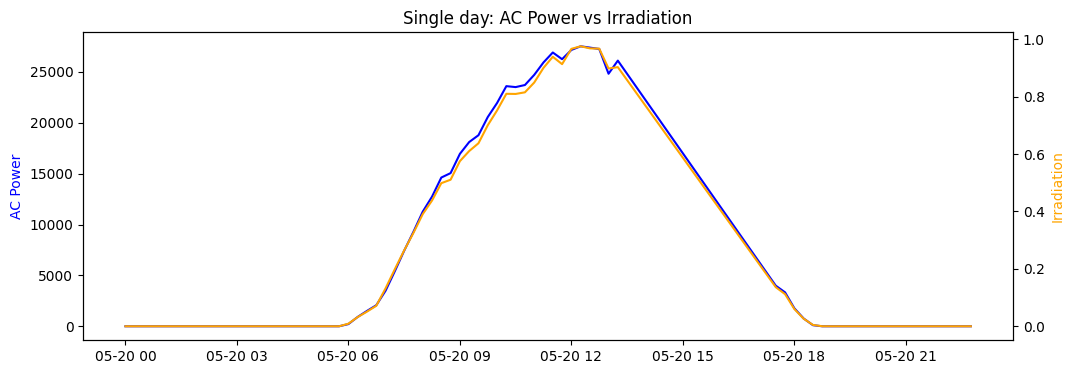

In [64]:
one_day = df_p1_merged[df_p1_merged['DATE_TIME'].dt.date == df_p1_merged['DATE_TIME'].dt.date.unique()[5]]

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.plot(one_day['DATE_TIME'], one_day['AC_POWER'], color='blue', label='AC Power')
ax2.plot(one_day['DATE_TIME'], one_day['IRRADIATION'], color='orange', label='Irradiation')

ax1.set_ylabel('AC Power', color='blue')
ax2.set_ylabel('Irradiation', color='orange')
plt.title('Single day: AC Power vs Irradiation')
plt.show()

All four signals show a clear daily cycle over the ~34-day period (May 15 - June 17, 2020). AC Power and Irradiation are tightly coupled - both peak during daylight hours and drop to zero at night, confirming irradiation as the primary driver of generation.
Ambient temperature follows a smoother diurnal cycle (roughly 21°C-35°C) and does not drop to zero at night, indicating it captures background thermal conditions rather than direct solar activity. Module temperature, however, spikes sharply during generation hours (up to ~62°C) and closely tracks the irradiation shape - suggesting it carries similar information to irradiation but also encodes thermal stress on the panels.
One notable observation: around 2020-05-29, AC Power shows a suppressed peak despite irradiation remaining normal. This may indicate a cloudy day, inverter curtailment, or a data anomaly -  worth investigating but not cleaned out, as the model should learn to handle such variability.
Based on this, IRRADIATION, AMBIENT_TEMPERATURE, MODULE_TEMPERATURE, and HOUR are selected as features. IRRADIATION is expected to dominate; temperature features provide secondary correction for real-world efficiency losses.

Linear regression is used as a baseline for comparing with other models in this work.

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
#features and target
features = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'HOUR']
df_p1_merged['HOUR'] = df_p1_merged['DATE_TIME'].dt.hour + df_p1_merged['DATE_TIME'].dt.minute/60
X = df_p1_merged[features]
y = df_p1_merged['AC_POWER']




X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

# evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE:  {mae:.1f} W')
print(f'RMSE: {rmse:.1f} W')
print(f'Max AC Power in data: {y.max():.1f} W')
print(f'MAE as % of max: {100*mae/y.max():.1f}%')

MAE:  502.6 W
RMSE: 804.3 W
Max AC Power in data: 29150.2 W
MAE as % of max: 1.7%


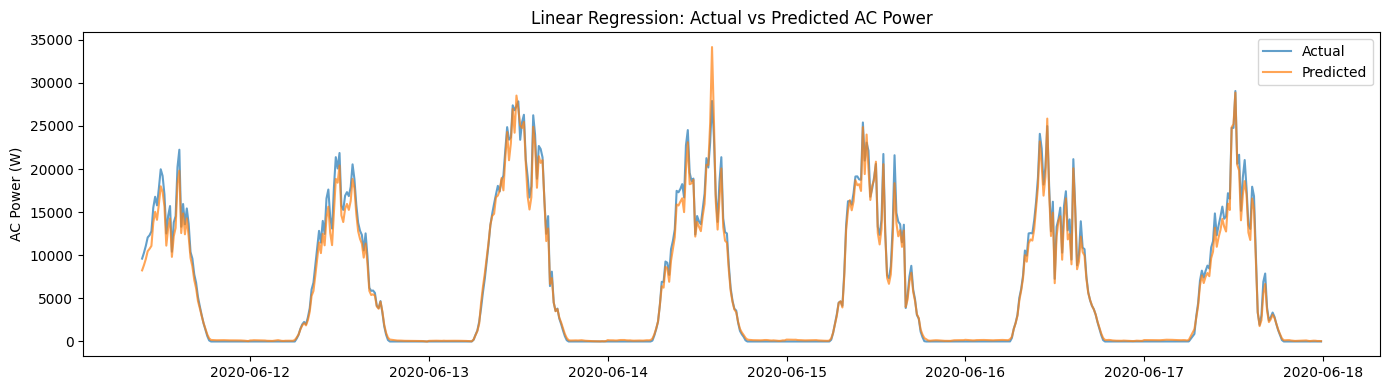

In [66]:
# plot predictions vs actual on test set
test_dates = df_p1_merged['DATE_TIME'].iloc[len(X_train):]

plt.figure(figsize=(14, 4))
plt.plot(test_dates, y_test.values, label='Actual', alpha=0.7)
plt.plot(test_dates, y_pred, label='Predicted', alpha=0.7)
plt.title('Linear Regression: Actual vs Predicted AC Power')
plt.ylabel('AC Power (W)')
plt.legend()
plt.tight_layout()
plt.show()

Linear Regression achieves 1.7% MAE, but assumes linear relationship between irradiation and power output. In reality, solar panels exhibit nonlinear behavior at high irradiation levels and the relationship with temperature is more complex. To capture these interactions, random forest is tried next.

In [70]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f'MAE:  {mae_rf:.1f} W')
print(f'RMSE: {rmse_rf:.1f} W')
print(f'MAE as % of max: {100*mae_rf/y.max():.1f}%')

# feature importances
print()
for feat, imp in sorted(zip(features, rf.feature_importances_), key=lambda x: -x[1]):
    print(f'{feat:25s}: {imp:.4f}')

MAE:  242.6 W
RMSE: 521.5 W
MAE as % of max: 0.8%

IRRADIATION              : 0.9967
MODULE_TEMPERATURE       : 0.0012
AMBIENT_TEMPERATURE      : 0.0011
HOUR                     : 0.0010


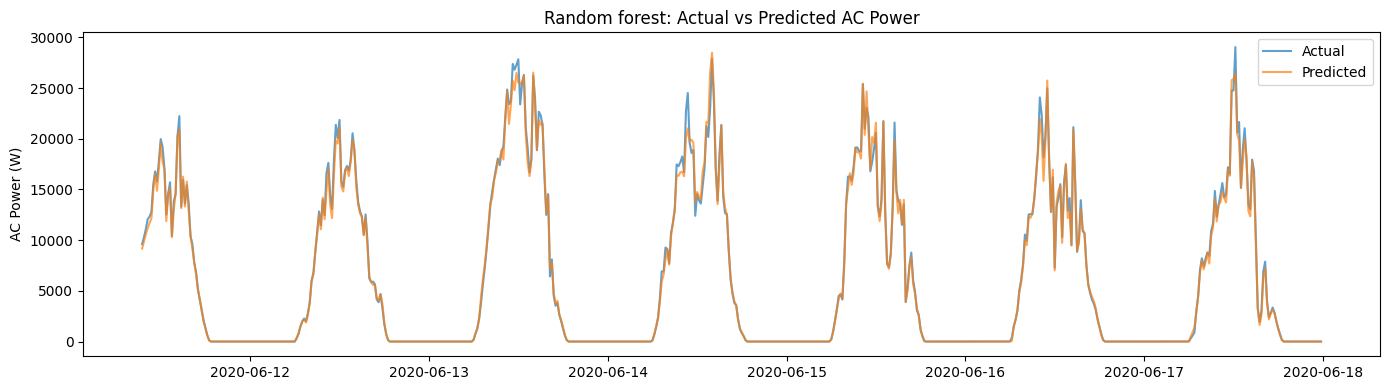

In [69]:
test_dates = df_p1_merged['DATE_TIME'].iloc[len(X_train):]

plt.figure(figsize=(14, 4))
plt.plot(test_dates, y_test.values, label='Actual', alpha=0.7)
plt.plot(test_dates, y_pred_rf, label='Predicted', alpha=0.7)
plt.title('Random forest: Actual vs Predicted AC Power')
plt.ylabel('AC Power (W)')
plt.legend()
plt.tight_layout()
plt.show()

The Random Forest achieves 0.8% MAE on the test set, and the predicted curve tracks actual output closely. However, given the small dataset size and the strong linear relationship between irradiation and power output, this low error may reflect the simplicity of the problem rather than model sophistication. No cross-validation was performed, and generalization to unseen weather conditions (e.g., different seasons) cannot be guaranteed. For this pipeline, we accept the forecast as a reasonable 24-hour estimate.

In [71]:
# daily total should be sum of 15min intervals converted to hours
# each reading is 15 min = 0.25 hours
# energy = power * time
daily_energy = df_p1_merged.groupby(df_p1_merged['DATE_TIME'].dt.date)['AC_POWER'].sum() * 0.25
print(f"Average daily energy: {daily_energy.mean():.1f} Wh")
print(f"Average daily energy: {daily_energy.mean()/1000:.1f} kWh")

Average daily energy: 155640.8 Wh
Average daily energy: 155.6 kWh


In [75]:
# in Watts (keeping consistent with your data)
BATTERY_CAPACITY = 50000  # 50 kWh battery
P_MIN = 10000             # 20% minimum charge (10 kWh)
P_MAX = 50000             # 100% maximum charge (50 kWh)
CHARGE_RATE = 12500       # max 12.5 kW charge per 15 min = 50 kW/hr rate
DISCHARGE_RATE = 12500    # same for discharge

# electricity prices (arbitrary for now, ratio matters more than absolute values)
C_BUY = 8                 # cost per kWh to buy from grid (Rs)
C_SELL = 4                # revenue per kWh to sell to grid (Rs)


The optimization requires two inputs beyond solar forecasts: a load profile and electricity pricing. Both are synthetic here, constructed to reflect realistic patterns rather than actual meter data.
The load profile follows a typical residential/commercial shape -  low consumption at night ( approx 3 kW), morning and evening peaks (8-9 kW), and moderate midday usage. Electricity pricing uses a time-of-use structure: cheap off-peak (midnight-8am), moderate shoulder periods, and expensive peak hours (2-6pm). This mirrors common utility tariff designs.
Battery parameters are illustrative (50 kWh capacity, 12.5 kW charge/discharge rate). They represent one third of the plant's average daily output of 155.6 kWh, a partial buffer rather than full storage. In practice battery sizing will be an optimization problem in itself.
The optimizer's decisions will be driven by the structure of these inputs - the relative price differences and load shape - rather than their absolute values. The pipeline is therefore valid as a proof of concept; replacing these with real smart meter and tariff data would make it production-ready.

In [76]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# ── 1. GET SOLAR PREDICTIONS FROM ML MODEL ──────────────────────────
# use one day of test data as our forecast horizon
# find a good day — pick a sunny day from test set
one_day = X_test.iloc[:96]          # first 96 rows = one day of 15min intervals
St_values = rf.predict(one_day)     # predicted AC power in Watts
# time of day pricing (Rs per Wh)
# cheap at night, expensive at peak
price_buy = np.array([
    *[0.004]*32,   # midnight to 8am — cheap
    *[0.008]*24,   # 8am to 2pm — medium
    *[0.012]*16,   # 2pm to 6pm — expensive peak
    *[0.006]*24    # 6pm to midnight — medium
])  # shape (96,)

# synthetic residential/commercial load in Watts
load = np.array([
    *[3000]*16,   # midnight to 4am — low load
    *[5000]*8,    # 4am to 6am — morning ramp
    *[8000]*16,   # 6am to 10am — morning peak
    *[6000]*20,   # 10am to 3pm — midday
    *[9000]*16,   # 3pm to 7pm — evening peak (highest)
    *[7000]*12,   # 7pm to 10pm — evening
    *[4000]*8,    # 10pm to midnight — winding down
])  # shape (96,)

price_sell = price_buy * 0.5  # sell at half buy price

T = len(St_values)                  # should be 96

# ── 2. BATTERY AND PRICE PARAMETERS ─────────────────────────────────
BATTERY_CAPACITY = 50000    # Wh — 50 kWh battery
P_MIN            = 10000    # Wh — minimum charge level (20%)
P_MAX            = 50000    # Wh — maximum charge level (100%)
CHARGE_RATE      = 12500    # W  — max charge per 15min interval
DISCHARGE_RATE   = 12500    # W  — max discharge per 15min interval
P_INIT           = 25000    # Wh — initial charge at start of day (50%)

C_BUY            = 8.0      # Rs per kWh — cost to buy from grid
C_SELL           = 4.0      # Rs per kWh — revenue from selling to grid

# convert prices to per-Wh for consistency with our units
C_BUY_W  = C_BUY  / 1000   # Rs per Wh
C_SELL_W = C_SELL / 1000   # Rs per Wh

# ── 3. BUILD GUROBI MODEL ────────────────────────────────────────────
model = gp.Model("SolarBattery")
model.setParam('OutputFlag', 1)     # show solver output

# decision variables
ct = model.addVars(T, vtype=GRB.BINARY,     name='ct')   # charging indicator
dt = model.addVars(T, vtype=GRB.BINARY,     name='dt')   # discharging indicator
Pt = model.addVars(T, vtype=GRB.CONTINUOUS, name='Pt')   # battery charge level
bt = model.addVars(T, vtype=GRB.CONTINUOUS, name='bt')   # power bought from grid
st = model.addVars(T, vtype=GRB.CONTINUOUS, name='st')   # power sold to grid

# ── 4. CONSTRAINTS ───────────────────────────────────────────────────

# initial battery state
model.addConstr(Pt[0] == P_INIT, name='init')

# battery dynamics — charge level evolves over time
for t in range(1, T):
    model.addConstr(
        Pt[t] == Pt[t-1] + ct[t] * CHARGE_RATE - dt[t] * DISCHARGE_RATE,
        name=f'dynamics_{t}'
    )

# battery limits
for t in range(T):
    model.addConstr(Pt[t] >= P_MIN, name=f'Pmin_{t}')
    model.addConstr(Pt[t] <= P_MAX, name=f'Pmax_{t}')

# can't charge and discharge at same time
for t in range(T):
    model.addConstr(ct[t] + dt[t] <= 1, name=f'mutex_{t}')

# power balance — energy in = energy out at every time step
for t in range(T):
    model.addConstr(
        St_values[t] + bt[t] + dt[t] * DISCHARGE_RATE == st[t] + ct[t] * CHARGE_RATE + load[t],
        name=f'balance_{t}'
    )
model.addConstr(
    gp.quicksum(st[t] for t in range(T)) <=
    gp.quicksum(St_values[t] for t in range(T)),
    name='sell_limit'
)
# non negativity
for t in range(T):
    model.addConstr(bt[t] >= 0, name=f'bt_pos_{t}')
    model.addConstr(st[t] >= 0, name=f'st_pos_{t}')
model.addConstr(Pt[T-1] >= P_INIT, name='final_state')
# ── 5. OBJECTIVE ─────────────────────────────────────────────────────
obj = gp.LinExpr()

for t in range(T):
    obj += price_buy[t] * bt[t] - price_sell[t] * st[t]

model.setObjective(obj, GRB.MINIMIZE)

# ── 6. SOLVE ─────────────────────────────────────────────────────────
model.optimize()

# ── 7. RESULTS ───────────────────────────────────────────────────────
if model.status == GRB.OPTIMAL:
    print(f"\nOptimal cost: Rs {model.objVal:.4f}")

    bt_vals = [bt[t].X for t in range(T)]
    st_vals = [st[t].X for t in range(T)]
    Pt_vals = [Pt[t].X for t in range(T)]
    ct_vals = [ct[t].X for t in range(T)]
    dt_vals = [dt[t].X for t in range(T)]
    Pt_vals = [Pt[t].X for t in range(T)]
    print(f"Total bought from grid: {sum(bt_vals):.1f} Wh")
    print(f"Total sold to grid:     {sum(st_vals):.1f} Wh")
    print(f"Total solar generated:  {sum(St_values):.1f} Wh")
    print(f"Final battery charge :  {Pt_vals[-1]: .1f} Wh")
else:
    print(f"Model status: {model.status}")

Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 674 rows, 480 columns and 1438 nonzeros (Min)
Model fingerprint: 0xcc906a3e
Model has 192 linear objective coefficients
Variable types: 288 continuous, 192 integer (192 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+04]
  Objective range  [2e-03, 1e-02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+05]

Presolve removed 483 rows and 194 columns
Presolve time: 0.01s
Presolved: 191 rows, 286 columns, 698 nonzeros
Variable types: 0 continuous, 286 integer (192 binary)
Found heuristic solution: objective 2895.5778946
Found heuristic solution: objective 2882.5008408
Found heuristic solution: objective 2841.0431926

Root relaxation: objective 2.608043e+03, 70 iterations, 

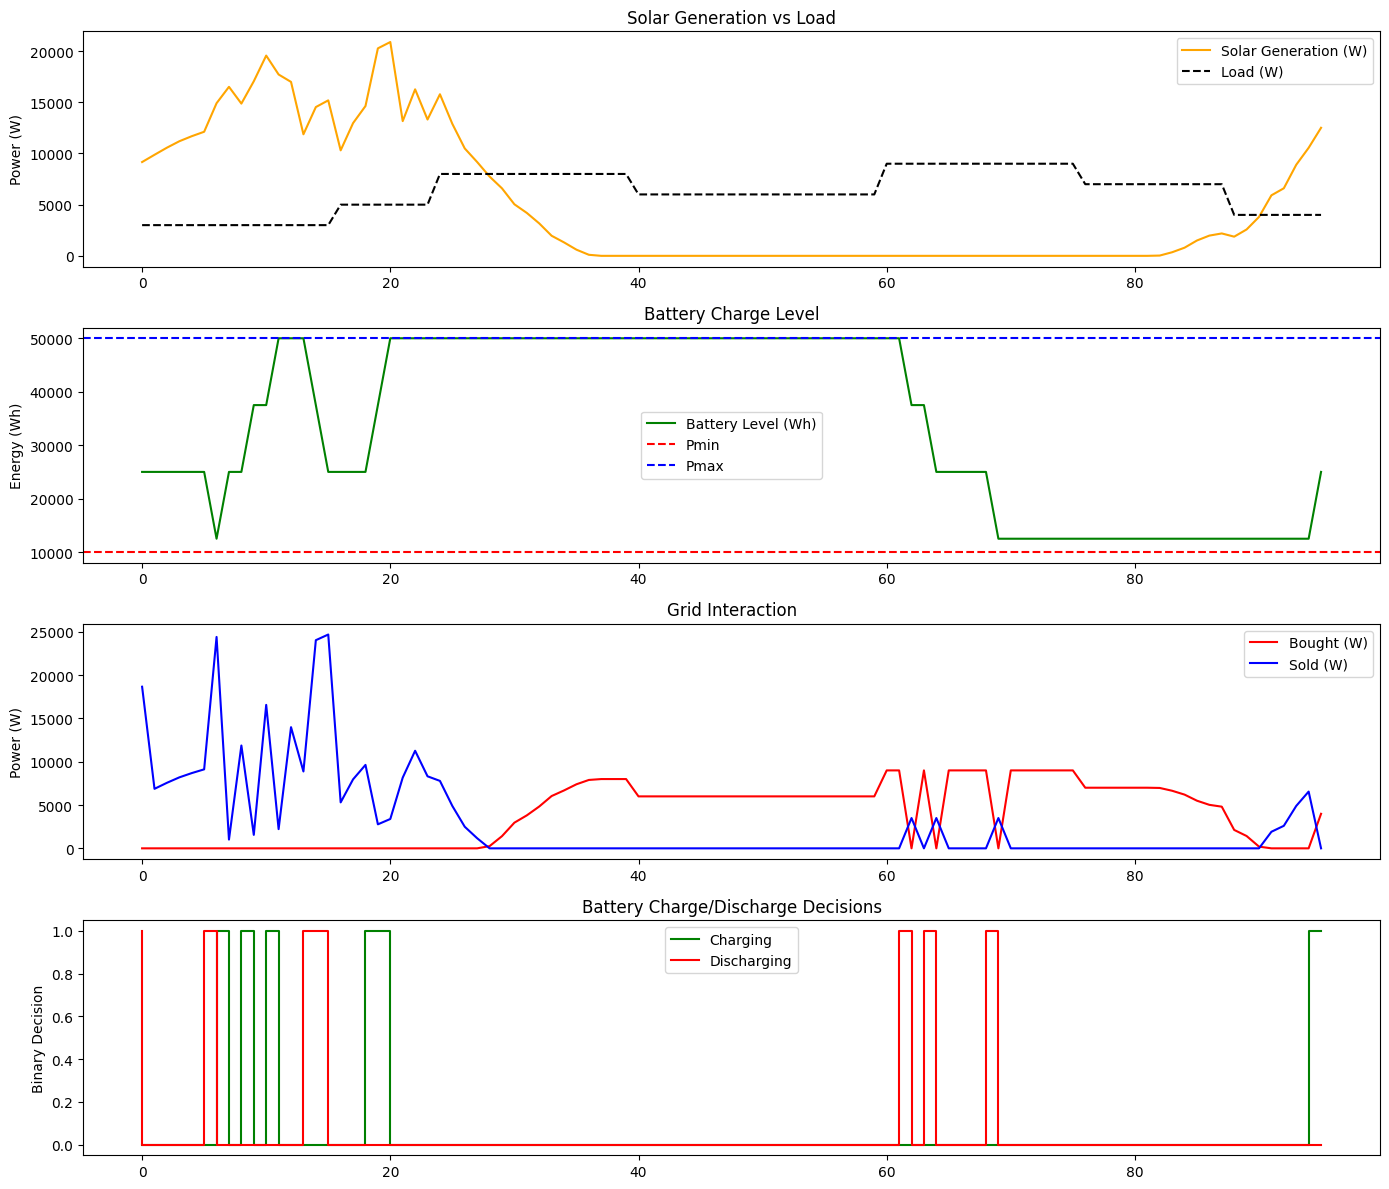

In [77]:
import matplotlib.pyplot as plt

bt_vals = [bt[t].X for t in range(T)]
st_vals = [st[t].X for t in range(T)]
Pt_vals = [Pt[t].X for t in range(T)]
ct_vals = [ct[t].X for t in range(T)]
dt_vals = [dt[t].X for t in range(T)]

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# solar generation vs load
axes[0].plot(St_values, color='orange', label='Solar Generation (W)')
axes[0].plot(load, color='black', linestyle='--', label='Load (W)')
axes[0].set_ylabel('Power (W)')
axes[0].legend()
axes[0].set_title('Solar Generation vs Load')

# battery level
axes[1].plot(Pt_vals, color='green', label='Battery Level (Wh)')
axes[1].axhline(P_MIN, color='red', linestyle='--', label='Pmin')
axes[1].axhline(P_MAX, color='blue', linestyle='--', label='Pmax')
axes[1].set_ylabel('Energy (Wh)')
axes[1].legend()
axes[1].set_title('Battery Charge Level')

# grid interaction
axes[2].plot(bt_vals, color='red', label='Bought (W)')
axes[2].plot(st_vals, color='blue', label='Sold (W)')
axes[2].set_ylabel('Power (W)')
axes[2].legend()
axes[2].set_title('Grid Interaction')

# charge discharge decisions
axes[3].step(range(T), ct_vals, color='green', label='Charging')
axes[3].step(range(T), dt_vals, color='red', label='Discharging')
axes[3].set_ylabel('Binary Decision')
axes[3].legend()
axes[3].set_title('Battery Charge/Discharge Decisions')

plt.tight_layout()
plt.show()



The optimizer produces a feasible schedule that respects all battery constraints - charge level stays between Pmin (10 kWh) and Pmax (50 kWh) throughout, and charging and discharging never occur simultaneously.

The broad pattern is rational: during the solar generation window (intervals 10-45), excess solar beyond load is sold back to the grid rather than wasted, while the battery charges opportunistically. Once solar drops to zero after interval ~45, the battery discharges to offset grid purchases during the expensive evening period, and grid buying takes over for remaining load.

However, two behaviors warrant scrutiny. First, the battery hits Pmax (50 kWh) and stays pinned there for a long stretch — this suggests the battery is oversized relative to the solar surplus on this particular day, or the charge rate is too conservative to fill it faster. Second, the charge/discharge decisions in the bottom plot are sparse and irregular rather than smooth — this is a consequence of the binary on/off formulation. A continuous charge rate variable would produce more realistic, granular scheduling.

The grid interaction plot shows selling (blue) dominating the solar hours and buying (red) taking over post-sunset, which is the correct qualitative behavior for a cost-minimizing system under time-of-use pricing.

As a proof of concept, this pipeline demonstrates that ML forecasts can be meaningfully coupled with optimization. Next steps toward a production system would include: real load and tariff data, continuous charge rate variables, and a rolling horizon replanning approach rather than a single 24-hour solve.

In [78]:
naive_cost = sum(price_buy[t] * max(load[t] - St_values[t], 0) for t in range(T))
print(f"Naive cost (no battery): Rs {naive_cost:.4f}")
print(f"Optimized cost:          Rs {model.objVal:.4f}")
print(f"Savings:                 Rs {naive_cost - model.objVal:.4f} ({100*(naive_cost - model.objVal)/naive_cost:.1f}%)")

Naive cost (no battery): Rs 3542.0060
Optimized cost:          Rs 2608.0432
Savings:                 Rs 933.9628 (26.4%)


Without a battery, the system would spend Rs 3524 buying from the grid whenever solar generation falls short of load. The optimized schedule reduces this to Rs 2608 - a 26.4% reduction - by storing cheap solar energy and discharging during expensive peak hours